05 — Final Evaluation and Error Analysis
This notebook evaluates the frozen model once on the untouched test period, compares it with persistence on identical rows, reports overall and per-city performance, and analyzes false negatives, severity, coverage, time, and geographic transfer.

No model fitting, retuning, feature selection, or threshold adjustment is performed.

In [10]:
from pathlib import Path
from IPython.display import Markdown, display

import hashlib
import json
import os
import sys

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)

if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")

    STORAGE_ROOT = Path(
        "/content/drive/MyDrive/CSE437_air_quality_group_18"
    )
else:
    STORAGE_ROOT = Path(
        os.environ.get("CSE437_STORAGE_ROOT", ".")
    ).resolve()

PATHS = {
    "processed": STORAGE_ROOT / "processed",
    "models": STORAGE_ROOT / "models" / "notebook_04",
    "figures": STORAGE_ROOT / "figures" / "notebook_05",
}

PATHS["figures"].mkdir(parents=True, exist_ok=True)

MODELING_FILE = PATHS["processed"] / "modeling_dataset.csv"
FEATURE_MANIFEST_FILE = (
    PATHS["processed"] / "notebook_03_feature_manifest.csv"
)
FEATURE_SUMMARY_FILE = (
    PATHS["processed"] / "notebook_03_feature_summary.json"
)
DAILY_FILE = PATHS["processed"] / "daily_air_quality.csv"
SPLIT_FILE = (
    PATHS["processed"] / "notebook_04_split_assignments.csv"
)
MODELING_SUMMARY_FILE = (
    PATHS["processed"] / "notebook_04_modeling_summary.json"
)
FINAL_MODEL_FILE = PATHS["models"] / "final_model.joblib"
FINAL_PROTOCOL_FILE = (
    PATHS["models"] / "final_model_protocol.json"
)

TEST_PREDICTIONS_FILE = (
    PATHS["processed"] / "notebook_05_test_predictions.csv"
)
OVERALL_RESULTS_FILE = (
    PATHS["processed"] / "notebook_05_overall_results.csv"
)
PER_CITY_RESULTS_FILE = (
    PATHS["processed"] / "notebook_05_per_city_results.csv"
)
FALSE_NEGATIVES_FILE = (
    PATHS["processed"] / "notebook_05_false_negatives.csv"
)
TEMPORAL_RESULTS_FILE = (
    PATHS["processed"] / "notebook_05_monthly_results.csv"
)
TRANSFER_RESULTS_FILE = (
    PATHS["processed"] / "notebook_05_transfer_results.csv"
)
COVERAGE_RESULTS_FILE = (
    PATHS["processed"] / "notebook_05_coverage_diagnostic.csv"
)
EVALUATION_SUMMARY_FILE = (
    PATHS["processed"] / "notebook_05_evaluation_summary.json"
)

PR_CURVE_FILE = PATHS["figures"] / "test_pr_curves.png"
CONFUSION_MATRIX_FILE = (
    PATHS["figures"] / "test_confusion_matrices.png"
)
PER_CITY_FIGURE_FILE = (
    PATHS["figures"] / "test_per_city_metrics.png"
)
TEMPORAL_FIGURE_FILE = (
    PATHS["figures"] / "test_monthly_recall.png"
)

print("Storage root:", STORAGE_ROOT)
print("Frozen model:", FINAL_MODEL_FILE)
print("Notebook 05 figure folder:", PATHS["figures"])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Storage root: /content/drive/MyDrive/CSE437_air_quality_group_18
Frozen model: /content/drive/MyDrive/CSE437_air_quality_group_18/models/notebook_04/final_model.joblib
Notebook 05 figure folder: /content/drive/MyDrive/CSE437_air_quality_group_18/figures/notebook_05


## 2. Load and Verify the Frozen Notebook 04 Handoff

Before accessing test outcomes, this section verifies:

- the Notebook 03 input checksums recorded by Notebook 04;
- the exact 65-feature order;
- the selected model and frozen decision threshold;
- the chronological split assignments;
- the 180 test dates per city;
- the exact one-day relationship between feature date and target date.

A failed assertion means the saved handoff has changed and evaluation must stop.

In [11]:
def calculate_sha256(file_path):
    digest = hashlib.sha256()

    with file_path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)

    return digest.hexdigest()


required_files = [
    MODELING_FILE,
    FEATURE_MANIFEST_FILE,
    FEATURE_SUMMARY_FILE,
    DAILY_FILE,
    SPLIT_FILE,
    MODELING_SUMMARY_FILE,
    FINAL_MODEL_FILE,
    FINAL_PROTOCOL_FILE,
]

for required_file in required_files:
    if not required_file.is_file():
        raise FileNotFoundError(
            f"Required file was not found: {required_file}"
        )

with FEATURE_SUMMARY_FILE.open("r", encoding="utf-8") as file:
    feature_summary = json.load(file)

with MODELING_SUMMARY_FILE.open("r", encoding="utf-8") as file:
    modeling_summary = json.load(file)

with FINAL_PROTOCOL_FILE.open("r", encoding="utf-8") as file:
    protocol = json.load(file)

modeling = pd.read_csv(
    MODELING_FILE,
    parse_dates=["feature_date", "target_date"],
)
feature_manifest = pd.read_csv(FEATURE_MANIFEST_FILE)
daily = pd.read_csv(DAILY_FILE, parse_dates=["date"])
split_assignments = pd.read_csv(
    SPLIT_FILE,
    parse_dates=["feature_date", "target_date"],
)
final_model = joblib.load(FINAL_MODEL_FILE)

SELECTED_CITIES = modeling_summary["selected_cities"]
SOURCE_CITY = protocol["source_city"]
TRANSFER_CITIES = protocol["transfer_cities"]
TARGET_COLUMN = protocol["target_column"]
FEATURE_COLUMNS = protocol["feature_columns"]
MODEL_NAME = protocol["model_family"]
FROZEN_THRESHOLD = float(protocol["threshold"])

IDENTIFIER_COLUMNS = [
    "city",
    "feature_date",
    "target_date",
]

OUTCOME_COLUMNS = [
    "target_daily_aqi",
    "next_day_unhealthy",
    "next_day_usg_or_worse",
]

checksum_files = {
    MODELING_FILE.name: MODELING_FILE,
    FEATURE_MANIFEST_FILE.name: FEATURE_MANIFEST_FILE,
    FEATURE_SUMMARY_FILE.name: FEATURE_SUMMARY_FILE,
}

for file_name, expected_checksum in protocol["input_checksums"].items():
    assert file_name in checksum_files
    assert (
        calculate_sha256(checksum_files[file_name])
        == expected_checksum
    )

assert modeling.shape == (6000, 71)
assert len(FEATURE_COLUMNS) == 65
assert feature_summary["feature_columns"] == FEATURE_COLUMNS
assert feature_manifest["feature"].tolist() == FEATURE_COLUMNS
assert feature_manifest["nearest_day_before_target"].ge(1).all()
assert protocol["feature_count"] == len(FEATURE_COLUMNS)
assert set(SELECTED_CITIES) == set(modeling["city"])
assert SOURCE_CITY == "Dhaka"
assert set(TRANSFER_CITIES) == set(SELECTED_CITIES) - {SOURCE_CITY}
assert TARGET_COLUMN == "next_day_unhealthy"
assert protocol["sensitivity_target_used_for_selection"] is False
assert modeling_summary["test_labels_used_for_selection"] is False
assert modeling_summary["test_predictions_created"] is False
assert modeling_summary["test_metrics_calculated"] is False
assert np.isclose(
    FROZEN_THRESHOLD,
    float(modeling_summary["selected_threshold"]),
)

assert list(modeling.columns) == [
    *IDENTIFIER_COLUMNS,
    *OUTCOME_COLUMNS,
    *FEATURE_COLUMNS,
]

assert not modeling.duplicated(
    ["city", "target_date"]
).any()

assert not split_assignments.duplicated(
    ["city", "target_date"]
).any()

assert (
    modeling["target_date"] - modeling["feature_date"]
).eq(pd.Timedelta(days=1)).all()

assert modeling[FEATURE_COLUMNS].notna().all().all()

assert np.isfinite(
    modeling[FEATURE_COLUMNS].to_numpy(dtype=float)
).all()

modeling_with_split = modeling.merge(
    split_assignments,
    on=IDENTIFIER_COLUMNS,
    how="inner",
    validate="one_to_one",
)

test_rows = (
    modeling_with_split.loc[
        modeling_with_split["split"].eq("test")
    ]
    .sort_values(["city", "target_date"])
    .reset_index(drop=True)
)

test_start = pd.Timestamp(
    protocol["split_dates"]["test_start"]
)
test_end = pd.Timestamp(
    protocol["split_dates"]["test_end"]
)

expected_test_dates = pd.date_range(
    test_start,
    test_end,
    freq="D",
)

test_counts = (
    test_rows.groupby("city")
    .size()
    .reindex(SELECTED_CITIES)
)

assert len(modeling_with_split) == 6000
assert len(test_rows) == 900
assert test_counts.eq(180).all()
assert test_rows["target_date"].min() == test_start
assert test_rows["target_date"].max() == test_end
assert set(test_rows[TARGET_COLUMN].unique()).issubset({0, 1})

for city in SELECTED_CITIES:
    city_dates = test_rows.loc[
        test_rows["city"].eq(city),
        "target_date",
    ].tolist()

    assert city_dates == list(expected_test_dates)

if hasattr(final_model, "feature_names_in_"):
    assert (
        final_model.feature_names_in_.tolist()
        == FEATURE_COLUMNS
    )

if hasattr(final_model, "n_features_in_"):
    assert (
        final_model.n_features_in_
        == len(FEATURE_COLUMNS)
    )

handoff_audit = pd.DataFrame({
    "item": [
        "Frozen model family",
        "Frozen threshold",
        "Historical predictors",
        "Test start",
        "Test end",
        "Test rows",
        "Rows per city",
    ],
    "verified_value": [
        MODEL_NAME,
        FROZEN_THRESHOLD,
        len(FEATURE_COLUMNS),
        test_start.date(),
        test_end.date(),
        len(test_rows),
        int(test_counts.min()),
    ],
})

display(handoff_audit)
display(
    test_counts.rename("test_rows").reset_index()
)

print(
    "Frozen Notebook 04 handoff verified. "
    "Test labels may now be evaluated once."
)

,item,verified_value
0,Frozen model family,Logistic Regression
1,Frozen threshold,0.00887
2,Historical predictors,65
3,Test start,2025-05-28
4,Test end,2025-11-23
5,Test rows,900
6,Rows per city,180


,city,test_rows
0,Dhaka,180
1,Dinājpur,180
2,Bherāmāra,180
3,Bhola,180
4,Cox’s Bāzār,180


Frozen Notebook 04 handoff verified. Test labels may now be evaluated once.


## 3. Score the Untouched Test Period Once

The frozen model is applied without refitting. Its saved validation-selected threshold converts probabilities into class predictions.

Persistence predicts that the target day will be unhealthy whenever `daily_aqi_lag1 > 150`. Both methods use exactly the same 900 test rows.

In [12]:
X_test = test_rows[FEATURE_COLUMNS].copy()
y_test = test_rows[TARGET_COLUMN].astype(int).copy()

positive_class_index = list(
    final_model.classes_
).index(1)

model_probability = final_model.predict_proba(
    X_test
)[:, positive_class_index]

model_prediction = (
    model_probability >= FROZEN_THRESHOLD
).astype(int)

persistence_prediction = (
    test_rows["daily_aqi_lag1"]
    .gt(150)
    .astype(int)
    .to_numpy()
)

persistence_score = persistence_prediction.astype(float)

test_predictions = test_rows[
    [
        *IDENTIFIER_COLUMNS,
        "target_daily_aqi",
        TARGET_COLUMN,
        "daily_aqi_lag1",
    ]
].copy()

test_predictions["model_probability"] = model_probability
test_predictions["model_prediction"] = model_prediction
test_predictions["persistence_score"] = persistence_score
test_predictions[
    "persistence_prediction"
] = persistence_prediction

assert X_test.shape == (900, 65)

assert (
    len(model_probability)
    == len(y_test)
    == len(persistence_prediction)
)

assert np.isfinite(model_probability).all()

assert (
    (model_probability >= 0)
    & (model_probability <= 1)
).all()

assert set(model_prediction).issubset({0, 1})
assert set(persistence_prediction).issubset({0, 1})

assert not test_predictions.duplicated(
    ["city", "target_date"]
).any()

print(
    "Untouched test rows scored once with "
    "the frozen model and threshold."
)

display(test_predictions.head())

Untouched test rows scored once with the frozen model and threshold.


,city,feature_date,target_date,target_daily_aqi,next_day_unhealthy,daily_aqi_lag1,model_probability,model_prediction,persistence_score,persistence_prediction
0,Bherāmāra,2025-05-27,2025-05-28,97.0,0,97.0,0.207347,1,0.0,0
1,Bherāmāra,2025-05-28,2025-05-29,54.0,0,97.0,0.012152,1,0.0,0
2,Bherāmāra,2025-05-29,2025-05-30,77.0,0,54.0,0.004961,0,0.0,0
3,Bherāmāra,2025-05-30,2025-05-31,98.0,0,77.0,0.044577,1,0.0,0
4,Bherāmāra,2025-05-31,2025-06-01,167.0,1,98.0,0.159912,1,0.0,0


## 4. Overall and Per-City Test Metrics

The primary metrics are:

1. average precision;
2. recall.

Precision, F1, accuracy, prevalence, and confusion-matrix counts are also reported.

Dhaka represents within-city performance because the model was developed using Dhaka. The other four cities represent geographic transfer.

In [13]:
def calculate_binary_metrics(y_true, score, prediction):
    y_true = np.asarray(y_true, dtype=int)
    score = np.asarray(score, dtype=float)
    prediction = np.asarray(prediction, dtype=int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        prediction,
        labels=[0, 1],
    ).ravel()

    positive_count = int(y_true.sum())

    return {
        "rows": int(len(y_true)),
        "positive_days": positive_count,
        "positive_rate": float(y_true.mean()),
        "average_precision": (
            float(average_precision_score(y_true, score))
            if positive_count > 0
            else np.nan
        ),
        "recall": float(
            recall_score(
                y_true,
                prediction,
                zero_division=0,
            )
        ),
        "precision": float(
            precision_score(
                y_true,
                prediction,
                zero_division=0,
            )
        ),
        "f1": float(
            f1_score(
                y_true,
                prediction,
                zero_division=0,
            )
        ),
        "accuracy": float(
            accuracy_score(y_true, prediction)
        ),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    }


METHODS = [
    (
        MODEL_NAME,
        "model_probability",
        "model_prediction",
    ),
    (
        "Persistence",
        "persistence_score",
        "persistence_prediction",
    ),
]

overall_records = []
per_city_records = []

for method, score_column, prediction_column in METHODS:
    overall_records.append({
        "scope": "All five cities pooled",
        "method": method,
        "threshold": (
            FROZEN_THRESHOLD
            if method == MODEL_NAME
            else 0.5
        ),
        **calculate_binary_metrics(
            test_predictions[TARGET_COLUMN],
            test_predictions[score_column],
            test_predictions[prediction_column],
        ),
    })

    for city in SELECTED_CITIES:
        city_rows = test_predictions.loc[
            test_predictions["city"].eq(city)
        ]

        per_city_records.append({
            "city": city,
            "evaluation_role": (
                "within-city"
                if city == SOURCE_CITY
                else "transfer"
            ),
            "method": method,
            "threshold": (
                FROZEN_THRESHOLD
                if method == MODEL_NAME
                else 0.5
            ),
            **calculate_binary_metrics(
                city_rows[TARGET_COLUMN],
                city_rows[score_column],
                city_rows[prediction_column],
            ),
        })

overall_results = pd.DataFrame(overall_records)
per_city_results = pd.DataFrame(per_city_records)

assert overall_results["rows"].eq(900).all()

assert (
    len(per_city_results)
    == len(SELECTED_CITIES) * len(METHODS)
)

assert per_city_results["rows"].eq(180).all()

display(overall_results.round(4))

display(
    per_city_results[
        [
            "city",
            "evaluation_role",
            "method",
            "positive_rate",
            "average_precision",
            "recall",
            "precision",
            "f1",
            "false_negative",
            "false_positive",
        ]
    ].round(4)
)

,scope,method,threshold,rows,positive_days,positive_rate,average_precision,recall,precision,f1,accuracy,true_negative,false_positive,false_negative,true_positive
0,All five cities pooled,Logistic Regression,0.0089,900,188,0.2089,0.9359,0.9947,0.3495,0.5173,0.6122,364,348,1,187
1,All five cities pooled,Persistence,0.5000,900,188,0.2089,0.7003,0.8032,0.8207,0.8118,0.9222,679,33,37,151


,city,evaluation_role,method,positive_rate,average_precision,recall,precision,f1,false_negative,false_positive
0,Dhaka,within-city,Logistic Regression,0.2222,0.9559,1.0000,0.3883,0.5594,0,63
1,Dinājpur,transfer,Logistic Regression,0.3556,0.9673,1.0000,0.3787,0.5494,0,105
2,Bherāmāra,transfer,Logistic Regression,0.3222,0.9737,1.0000,0.3841,0.5550,0,93
3,Bhola,transfer,Logistic Regression,0.0833,0.8886,1.0000,0.2308,0.3750,0,50
4,Cox’s Bāzār,transfer,Logistic Regression,0.0611,0.6280,0.9091,0.2128,0.3448,1,37
5,Dhaka,within-city,Persistence,0.2222,0.7195,0.8250,0.8250,0.8250,7,7
6,Dinājpur,transfer,Persistence,0.3556,0.7578,0.8281,0.8413,0.8346,11,10
7,Bherāmāra,transfer,Persistence,0.3222,0.7763,0.8448,0.8596,0.8522,9,8
8,Bhola,transfer,Persistence,0.0833,0.5040,0.6667,0.7143,0.6897,5,4
9,Cox’s Bāzār,transfer,Persistence,0.0611,0.3551,0.5455,0.6000,0.5714,5,4


## 5. Precision–Recall Curves and Confusion Matrices

The precision–recall curve shows the model's performance across probability thresholds. Persistence has only a hard 0/1 score, so its curve is much coarser.

The confusion matrices use the model's already-frozen threshold and show the final numbers of true negatives, false positives, false negatives, and true positives.

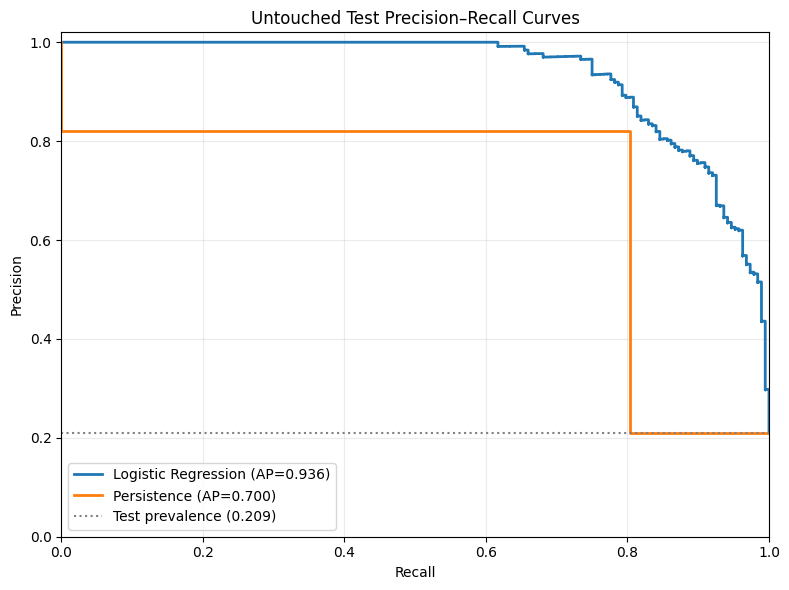

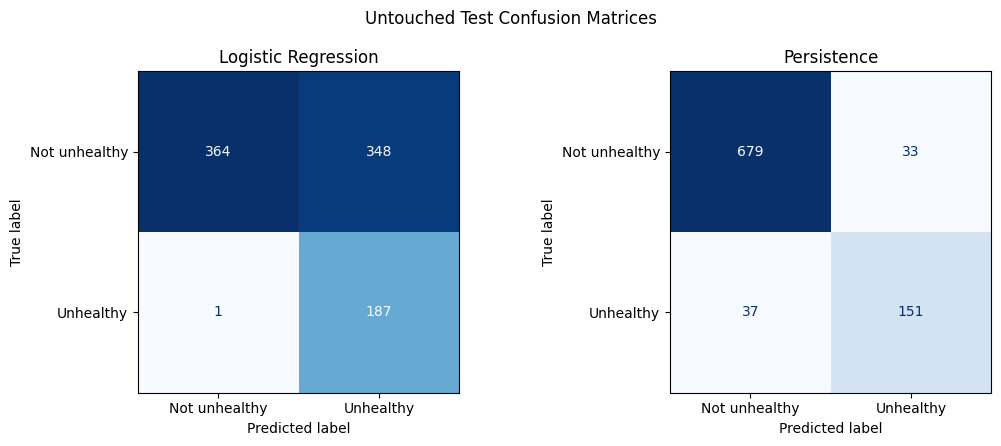

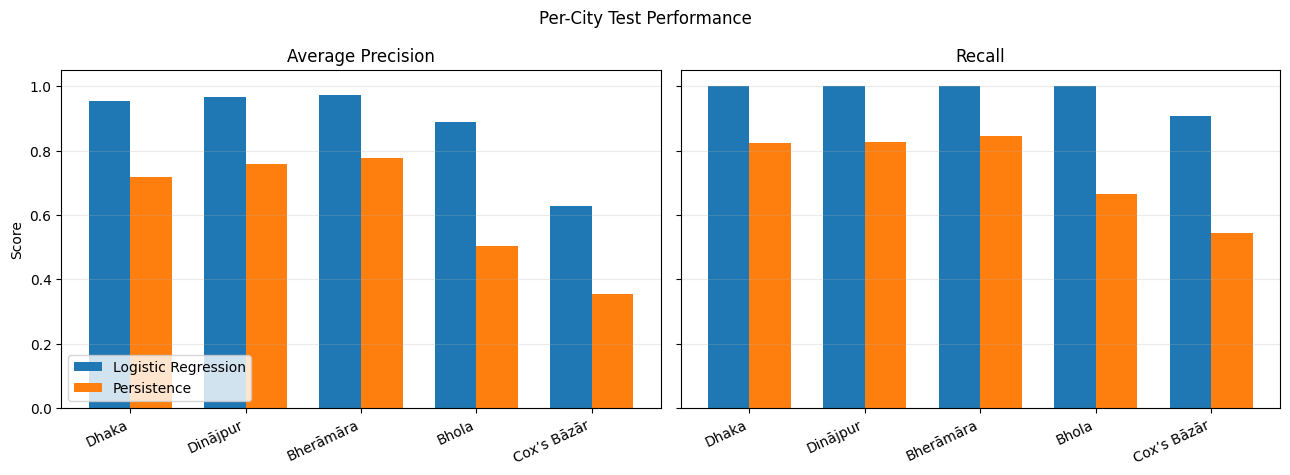

Saved: /content/drive/MyDrive/CSE437_air_quality_group_18/figures/notebook_05/test_pr_curves.png
Saved: /content/drive/MyDrive/CSE437_air_quality_group_18/figures/notebook_05/test_confusion_matrices.png
Saved: /content/drive/MyDrive/CSE437_air_quality_group_18/figures/notebook_05/test_per_city_metrics.png


In [14]:
fig, axis = plt.subplots(figsize=(8, 6))

for method, score_column, _ in METHODS:
    precision_values, recall_values, _ = (
        precision_recall_curve(
            test_predictions[TARGET_COLUMN],
            test_predictions[score_column],
        )
    )

    method_ap = overall_results.loc[
        overall_results["method"].eq(method),
        "average_precision",
    ].iloc[0]

    axis.step(
        recall_values,
        precision_values,
        where="post",
        linewidth=2,
        label=f"{method} (AP={method_ap:.3f})",
    )

axis.axhline(
    test_predictions[TARGET_COLUMN].mean(),
    color="gray",
    linestyle=":",
    label=(
        "Test prevalence "
        f"({test_predictions[TARGET_COLUMN].mean():.3f})"
    ),
)

axis.set(
    title="Untouched Test Precision–Recall Curves",
    xlabel="Recall",
    ylabel="Precision",
    xlim=(0, 1),
    ylim=(0, 1.02),
)

axis.grid(alpha=0.25)
axis.legend(loc="lower left")

fig.tight_layout()
fig.savefig(
    PR_CURVE_FILE,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
)

for axis, (
    method,
    _,
    prediction_column,
) in zip(axes, METHODS):
    matrix = confusion_matrix(
        test_predictions[TARGET_COLUMN],
        test_predictions[prediction_column],
        labels=[0, 1],
    )

    ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=[
            "Not unhealthy",
            "Unhealthy",
        ],
    ).plot(
        ax=axis,
        cmap="Blues",
        colorbar=False,
        values_format="d",
    )

    axis.set_title(method)

fig.suptitle(
    "Untouched Test Confusion Matrices"
)

fig.tight_layout()
fig.savefig(
    CONFUSION_MATRIX_FILE,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

x_positions = np.arange(
    len(SELECTED_CITIES)
)

bar_width = 0.36

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.8),
    sharey=True,
)

for axis, metric in zip(
    axes,
    ["average_precision", "recall"],
):
    for offset, (
        method,
        _,
        _,
    ) in zip(
        [-bar_width / 2, bar_width / 2],
        METHODS,
    ):
        values = (
            per_city_results.loc[
                per_city_results["method"].eq(method)
            ]
            .set_index("city")
            .reindex(SELECTED_CITIES)[metric]
        )

        axis.bar(
            x_positions + offset,
            values,
            bar_width,
            label=method,
        )

    axis.set_title(
        metric.replace("_", " ").title()
    )

    axis.set_xticks(x_positions)

    axis.set_xticklabels(
        SELECTED_CITIES,
        rotation=25,
        ha="right",
    )

    axis.set_ylim(0, 1.05)
    axis.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Score")
axes[0].legend(loc="lower left")

fig.suptitle("Per-City Test Performance")
fig.tight_layout()

fig.savefig(
    PER_CITY_FIGURE_FILE,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", PR_CURVE_FILE)
print("Saved:", CONFUSION_MATRIX_FILE)
print("Saved:", PER_CITY_FIGURE_FILE)

## 6. False-Negative and Severity Analysis

False negatives are examined first because they represent unhealthy days that the method failed to warn about.

For every city and method, this section reports:

- the number of missed unhealthy days;
- the proportion of actual unhealthy days missed;
- mean, median, and maximum AQI among missed days;
- counts across AQI severity bands;
- the 25 most severe individual false negatives.

The AQI bands are used only to describe error severity. They do not redefine the target.

In [15]:
base_columns = [
    *IDENTIFIER_COLUMNS,
    "target_daily_aqi",
    TARGET_COLUMN,
    "daily_aqi_lag1",
]

prediction_records = []

for method, score_column, prediction_column in METHODS:
    method_rows = test_predictions[
        base_columns
    ].copy()

    method_rows["method"] = method

    method_rows["score"] = (
        test_predictions[score_column].to_numpy()
    )

    method_rows["prediction"] = (
        test_predictions[
            prediction_column
        ].to_numpy()
    )

    prediction_records.append(method_rows)

prediction_records = pd.concat(
    prediction_records,
    ignore_index=True,
)

prediction_records["error_type"] = np.select(
    [
        prediction_records[TARGET_COLUMN].eq(1)
        & prediction_records["prediction"].eq(0),

        prediction_records[TARGET_COLUMN].eq(0)
        & prediction_records["prediction"].eq(1),

        prediction_records[TARGET_COLUMN].eq(1)
        & prediction_records["prediction"].eq(1),
    ],
    [
        "False negative",
        "False positive",
        "True positive",
    ],
    default="True negative",
)

false_negatives = prediction_records.loc[
    prediction_records["error_type"].eq(
        "False negative"
    )
].copy()

false_negatives["aqi_above_150"] = (
    false_negatives["target_daily_aqi"] - 150
)

severity_labels = [
    "151–200",
    "201–300",
    ">300",
]

false_negatives["severity_band"] = pd.cut(
    false_negatives["target_daily_aqi"],
    bins=[150, 200, 300, np.inf],
    labels=severity_labels,
    right=True,
)

positive_days_by_city = (
    test_predictions.groupby("city")[
        TARGET_COLUMN
    ]
    .sum()
    .reindex(SELECTED_CITIES)
    .rename("actual_positive_days")
)

fn_counts = (
    prediction_records.assign(
        is_false_negative=(
            prediction_records["error_type"]
            .eq("False negative")
        )
    )
    .groupby(
        ["method", "city"]
    )["is_false_negative"]
    .sum()
    .rename("false_negative_days")
    .reset_index()
)

fn_severity = (
    false_negatives.groupby(
        ["method", "city"],
        observed=True,
    )
    .agg(
        mean_missed_aqi=(
            "target_daily_aqi",
            "mean",
        ),
        median_missed_aqi=(
            "target_daily_aqi",
            "median",
        ),
        maximum_missed_aqi=(
            "target_daily_aqi",
            "max",
        ),
    )
    .reset_index()
)

false_negative_summary = (
    fn_counts.merge(
        fn_severity,
        on=["method", "city"],
        how="left",
    )
    .merge(
        positive_days_by_city.reset_index(),
        on="city",
        how="left",
    )
)

false_negative_summary[
    "miss_rate_among_positive_days"
] = (
    false_negative_summary[
        "false_negative_days"
    ]
    / false_negative_summary[
        "actual_positive_days"
    ]
)

if false_negatives.empty:
    severity_table = pd.DataFrame(
        columns=[
            "method",
            "city",
            *severity_labels,
        ]
    )
else:
    severity_table = (
        pd.crosstab(
            [
                false_negatives["method"],
                false_negatives["city"],
            ],
            false_negatives["severity_band"],
            dropna=False,
        )
        .reindex(
            columns=severity_labels,
            fill_value=0,
        )
        .reset_index()
    )

display(
    false_negative_summary.round(4)
)

display(severity_table)

if false_negatives.empty:
    print(
        "No false negatives occurred "
        "for either method."
    )
else:
    display(
        false_negatives[
            [
                "method",
                "city",
                "target_date",
                "target_daily_aqi",
                "daily_aqi_lag1",
                "score",
                "severity_band",
            ]
        ]
        .sort_values(
            "target_daily_aqi",
            ascending=False,
        )
        .head(25)
        .round(4)
    )

,method,city,false_negative_days,mean_missed_aqi,median_missed_aqi,maximum_missed_aqi,actual_positive_days,miss_rate_among_positive_days
0,Logistic Regression,Bherāmāra,0,NaN,NaN,NaN,58,0.0000
1,Logistic Regression,Bhola,0,NaN,NaN,NaN,15,0.0000
2,Logistic Regression,Cox’s Bāzār,1,162.0000,162.0,162.0,11,0.0909
3,Logistic Regression,Dhaka,0,NaN,NaN,NaN,40,0.0000
4,Logistic Regression,Dinājpur,0,NaN,NaN,NaN,64,0.0000
5,Persistence,Bherāmāra,9,159.2222,153.0,175.0,58,0.1552
6,Persistence,Bhola,5,154.6000,154.0,159.0,15,0.3333
7,Persistence,Cox’s Bāzār,5,160.8000,162.0,169.0,11,0.4545
8,Persistence,Dhaka,7,155.8571,157.0,163.0,40,0.1750
9,Persistence,Dinājpur,11,155.8182,154.0,167.0,64,0.1719


severity_band,method,city,151–200,201–300,>300
0,Logistic Regression,Bherāmāra,0,0,0
1,Logistic Regression,Bhola,0,0,0
2,Logistic Regression,Cox’s Bāzār,1,0,0
3,Logistic Regression,Dhaka,0,0,0
4,Logistic Regression,Dinājpur,0,0,0
5,Persistence,Bherāmāra,9,0,0
6,Persistence,Bhola,5,0,0
7,Persistence,Cox’s Bāzār,5,0,0
8,Persistence,Dhaka,7,0,0
9,Persistence,Dinājpur,11,0,0


,method,city,target_date,target_daily_aqi,daily_aqi_lag1,score,severity_band
1059,Persistence,Bherāmāra,2025-11-03,175.0,98.0,0.0000,151–200
1032,Persistence,Bherāmāra,2025-10-07,174.0,134.0,0.0000,151–200
1426,Persistence,Cox’s Bāzār,2025-11-10,169.0,144.0,0.0000,151–200
1779,Persistence,Dinājpur,2025-11-03,167.0,120.0,0.0000,151–200
904,Persistence,Bherāmāra,2025-06-01,167.0,98.0,0.0000,151–200
1555,Persistence,Dhaka,2025-09-20,163.0,120.0,0.0000,151–200
1439,Persistence,Cox’s Bāzār,2025-11-23,163.0,149.0,0.0000,151–200
498,Logistic Regression,Cox’s Bāzār,2025-10-13,162.0,49.0,0.0043,151–200
1398,Persistence,Cox’s Bāzār,2025-10-13,162.0,49.0,0.0000,151–200
1605,Persistence,Dhaka,2025-11-09,160.0,129.0,0.0000,151–200


## 7. Measurement-Coverage Error Analysis

Coverage is checked for both the feature date and target date.

If every observation and valid-hour count remains constant at 24, coverage cannot explain why some predictions were correct and others were incorrect. The conclusion is produced from the displayed values rather than assumed.

In [16]:
POLLUTANTS = [
    "pm10",
    "pm25",
    "co",
    "no2",
    "so2",
    "o3",
]

COVERAGE_COLUMNS = [
    "observed_rows",
    "observed_hours",
    "aqi_valid_hours",
    *[
        f"{pollutant}_valid_hours"
        for pollutant in POLLUTANTS
    ],
]

assert set(
    [
        "city",
        "date",
        *COVERAGE_COLUMNS,
    ]
).issubset(daily.columns)

feature_coverage = daily[
    [
        "city",
        "date",
        *COVERAGE_COLUMNS,
    ]
].rename(
    columns={
        "date": "feature_date",
        **{
            column: f"feature_{column}"
            for column in COVERAGE_COLUMNS
        },
    }
)

target_coverage = daily[
    [
        "city",
        "date",
        *COVERAGE_COLUMNS,
    ]
].rename(
    columns={
        "date": "target_date",
        **{
            column: f"target_{column}"
            for column in COVERAGE_COLUMNS
        },
    }
)

test_coverage = (
    test_rows[IDENTIFIER_COLUMNS]
    .merge(
        feature_coverage,
        on=["city", "feature_date"],
        how="left",
        validate="many_to_one",
    )
    .merge(
        target_coverage,
        on=["city", "target_date"],
        how="left",
        validate="many_to_one",
    )
)

all_coverage_columns = [
    f"{role}_{column}"
    for role in ["feature", "target"]
    for column in COVERAGE_COLUMNS
]

assert len(test_coverage) == len(test_rows)

assert test_coverage[
    all_coverage_columns
].notna().all().all()

coverage_diagnostic = pd.DataFrame({
    "minimum": (
        test_coverage[
            all_coverage_columns
        ].min()
    ),
    "maximum": (
        test_coverage[
            all_coverage_columns
        ].max()
    ),
    "unique_values": (
        test_coverage[
            all_coverage_columns
        ].nunique()
    ),
}).rename_axis(
    "coverage_measure"
).reset_index()

prediction_records = prediction_records.merge(
    test_coverage[
        [
            *IDENTIFIER_COLUMNS,
            "feature_observed_hours",
            "feature_aqi_valid_hours",
            "target_observed_hours",
            "target_aqi_valid_hours",
        ]
    ],
    on=IDENTIFIER_COLUMNS,
    how="left",
    validate="many_to_one",
)

coverage_by_error = (
    prediction_records.groupby(
        ["method", "error_type"]
    )
    .agg(
        rows=("target_date", "size"),
        mean_feature_observed_hours=(
            "feature_observed_hours",
            "mean",
        ),
        mean_feature_aqi_valid_hours=(
            "feature_aqi_valid_hours",
            "mean",
        ),
        mean_target_observed_hours=(
            "target_observed_hours",
            "mean",
        ),
        mean_target_aqi_valid_hours=(
            "target_aqi_valid_hours",
            "mean",
        ),
    )
    .reset_index()
)

coverage_varies = (
    coverage_diagnostic[
        "unique_values"
    ].gt(1).any()
)

display(coverage_diagnostic)
display(coverage_by_error.round(2))

if coverage_varies:
    print(
        "Coverage varies, so the error-group "
        "coverage table must be interpreted."
    )
else:
    print(
        "All feature-day and target-day coverage "
        "counts are constant. Reduced measurement "
        "coverage cannot explain differences "
        "between test errors."
    )

,coverage_measure,minimum,maximum,unique_values
0,feature_observed_rows,24,24,1
1,feature_observed_hours,24,24,1
2,feature_aqi_valid_hours,24,24,1
3,feature_pm10_valid_hours,24,24,1
4,feature_pm25_valid_hours,24,24,1
5,feature_co_valid_hours,24,24,1
6,feature_no2_valid_hours,24,24,1
7,feature_so2_valid_hours,24,24,1
8,feature_o3_valid_hours,24,24,1
9,target_observed_rows,24,24,1


,method,error_type,rows,mean_feature_observed_hours,mean_feature_aqi_valid_hours,mean_target_observed_hours,mean_target_aqi_valid_hours
0,Logistic Regression,False negative,1,24.0,24.0,24.0,24.0
1,Logistic Regression,False positive,348,24.0,24.0,24.0,24.0
2,Logistic Regression,True negative,364,24.0,24.0,24.0,24.0
3,Logistic Regression,True positive,187,24.0,24.0,24.0,24.0
4,Persistence,False negative,37,24.0,24.0,24.0,24.0
5,Persistence,False positive,33,24.0,24.0,24.0,24.0
6,Persistence,True negative,679,24.0,24.0,24.0,24.0
7,Persistence,True positive,151,24.0,24.0,24.0,24.0


All feature-day and target-day coverage counts are constant. Reduced measurement coverage cannot explain differences between test errors.


## 8. Temporal Error Analysis

Performance is summarized by target month to determine whether recall and error counts were stable throughout the untouched test period.

These are descriptive test-period diagnostics. They are not used to modify the model or threshold.

,target_month,method,rows,positive_rate,average_precision,recall,precision,false_negative,false_positive
0,2025-05,Logistic Regression,20,0.0000,NaN,0.0000,0.0000,0,10
1,2025-05,Persistence,20,0.0000,NaN,0.0000,0.0000,0,1
2,2025-06,Logistic Regression,150,0.1933,0.9613,1.0000,0.3187,0,62
3,2025-06,Persistence,150,0.1933,0.7182,0.8276,0.8276,5,5
4,2025-07,Logistic Regression,155,0.0452,0.9821,1.0000,0.1167,0,53
5,2025-07,Persistence,155,0.0452,0.7411,0.8571,0.8571,1,1
6,2025-08,Logistic Regression,155,0.0258,0.7470,1.0000,0.0656,0,57
7,2025-08,Persistence,155,0.0258,0.0819,0.2500,0.2500,3,3
8,2025-09,Logistic Regression,150,0.0533,0.5667,1.0000,0.1039,0,69
9,2025-09,Persistence,150,0.0533,0.1940,0.3750,0.4286,5,4


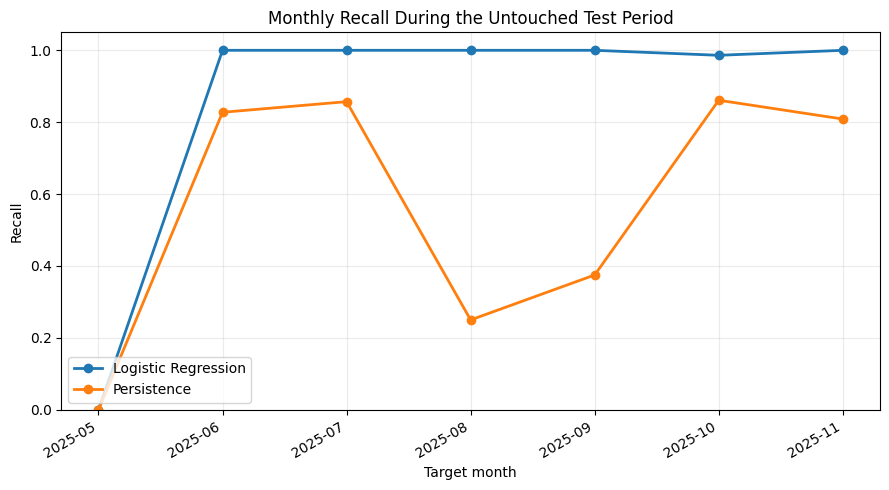

In [17]:
prediction_records["target_month"] = (
    prediction_records["target_date"]
    .dt.to_period("M")
    .astype(str)
)

temporal_records = []

for (
    method,
    month,
), month_rows in prediction_records.groupby(
    ["method", "target_month"],
    sort=True,
):
    temporal_records.append({
        "method": method,
        "target_month": month,
        **calculate_binary_metrics(
            month_rows[TARGET_COLUMN],
            month_rows["score"],
            month_rows["prediction"],
        ),
    })

temporal_results = (
    pd.DataFrame(temporal_records)
    .sort_values(
        ["target_month", "method"]
    )
    .reset_index(drop=True)
)

display(
    temporal_results[
        [
            "target_month",
            "method",
            "rows",
            "positive_rate",
            "average_precision",
            "recall",
            "precision",
            "false_negative",
            "false_positive",
        ]
    ].round(4)
)

months = sorted(
    prediction_records[
        "target_month"
    ].unique()
)

x_positions = np.arange(len(months))

fig, axis = plt.subplots(
    figsize=(9, 5)
)

for method, _, _ in METHODS:
    values = (
        temporal_results.loc[
            temporal_results["method"].eq(method)
        ]
        .set_index("target_month")
        .reindex(months)["recall"]
    )

    axis.plot(
        x_positions,
        values,
        marker="o",
        linewidth=2,
        label=method,
    )

axis.set(
    title=(
        "Monthly Recall During the "
        "Untouched Test Period"
    ),
    xlabel="Target month",
    ylabel="Recall",
    ylim=(0, 1.05),
)

axis.set_xticks(x_positions)

axis.set_xticklabels(
    months,
    rotation=30,
    ha="right",
)

axis.grid(alpha=0.25)
axis.legend(loc="lower left")

fig.tight_layout()

fig.savefig(
    TEMPORAL_FIGURE_FILE,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

## 9. Dhaka-to-Smaller-City Transfer Analysis

The model was fitted only on Dhaka development data.

This section compares:

- Dhaka within-city test performance;
- the four smaller cities pooled together;
- every transfer city's performance relative to Dhaka.

Negative gaps indicate that the model performed worse in the transfer city than in Dhaka.

In [18]:
prediction_records["evaluation_scope"] = np.where(
    prediction_records["city"].eq(SOURCE_CITY),
    "Dhaka within-city",
    "Four-city transfer pooled",
)

transfer_records = []

for (
    scope,
    method,
), scope_rows in prediction_records.groupby(
    ["evaluation_scope", "method"],
    sort=False,
):
    transfer_records.append({
        "evaluation_scope": scope,
        "method": method,
        **calculate_binary_metrics(
            scope_rows[TARGET_COLUMN],
            scope_rows["score"],
            scope_rows["prediction"],
        ),
    })

transfer_results = pd.DataFrame(
    transfer_records
)

model_city_results = per_city_results.loc[
    per_city_results["method"].eq(MODEL_NAME),
    [
        "city",
        "average_precision",
        "recall",
        "precision",
        "f1",
    ],
].copy()

dhaka_model_metrics = (
    model_city_results.loc[
        model_city_results["city"].eq(
            SOURCE_CITY
        )
    ].iloc[0]
)

transfer_city_gaps = (
    model_city_results.loc[
        model_city_results["city"].isin(
            TRANSFER_CITIES
        )
    ].copy()
)

transfer_city_gaps[
    "average_precision_gap_from_dhaka"
] = (
    transfer_city_gaps["average_precision"]
    - dhaka_model_metrics["average_precision"]
)

transfer_city_gaps[
    "recall_gap_from_dhaka"
] = (
    transfer_city_gaps["recall"]
    - dhaka_model_metrics["recall"]
)

display(transfer_results.round(4))
display(transfer_city_gaps.round(4))

,evaluation_scope,method,rows,positive_days,positive_rate,average_precision,recall,precision,f1,accuracy,true_negative,false_positive,false_negative,true_positive
0,Four-city transfer pooled,Logistic Regression,720,148,0.2056,0.9376,0.9932,0.3403,0.5069,0.6028,287,285,1,147
1,Dhaka within-city,Logistic Regression,180,40,0.2222,0.9559,1.0000,0.3883,0.5594,0.6500,77,63,0,40
2,Four-city transfer pooled,Persistence,720,148,0.2056,0.6950,0.7973,0.8194,0.8082,0.9222,546,26,30,118
3,Dhaka within-city,Persistence,180,40,0.2222,0.7195,0.8250,0.8250,0.8250,0.9222,133,7,7,33


,city,average_precision,recall,precision,f1,average_precision_gap_from_dhaka,recall_gap_from_dhaka
1,Dinājpur,0.9673,1.0000,0.3787,0.5494,0.0114,0.0000
2,Bherāmāra,0.9737,1.0000,0.3841,0.5550,0.0177,0.0000
3,Bhola,0.8886,1.0000,0.2308,0.3750,-0.0674,0.0000
4,Cox’s Bāzār,0.6280,0.9091,0.2128,0.3448,-0.3280,-0.0909


## 10. Final Verdict and Saved Notebook 05 Handoff

The project defines success strictly: the machine-learning model must exceed persistence on both pooled test average precision and pooled test recall.

The following cell produces the evidence-based conclusion, records how many individual cities satisfy the same condition, saves all final outputs, and verifies the saved files.

In [19]:
model_overall = overall_results.loc[
    overall_results["method"].eq(MODEL_NAME)
].iloc[0]

persistence_overall = overall_results.loc[
    overall_results["method"].eq(
        "Persistence"
    )
].iloc[0]

model_city_comparison = (
    per_city_results.loc[
        per_city_results["method"].eq(
            MODEL_NAME
        ),
        [
            "city",
            "average_precision",
            "recall",
        ],
    ]
    .merge(
        per_city_results.loc[
            per_city_results["method"].eq(
                "Persistence"
            ),
            [
                "city",
                "average_precision",
                "recall",
            ],
        ],
        on="city",
        suffixes=(
            "_model",
            "_persistence",
        ),
        validate="one_to_one",
    )
)

model_city_comparison[
    "beat_persistence_on_both_primary_metrics"
] = (
    model_city_comparison[
        "average_precision_model"
    ].gt(
        model_city_comparison[
            "average_precision_persistence"
        ]
    )
    & model_city_comparison[
        "recall_model"
    ].gt(
        model_city_comparison[
            "recall_persistence"
        ]
    )
)

display(
    model_city_comparison.round(4)
)

cities_beating_persistence = int(
    model_city_comparison[
        "beat_persistence_on_both_primary_metrics"
    ].sum()
)

beat_persistence = bool(
    model_overall["average_precision"]
    > persistence_overall["average_precision"]
    and model_overall["recall"]
    > persistence_overall["recall"]
)

verdict = (
    "Yes. The frozen machine-learning model beat "
    "persistence on both pooled test average "
    "precision and recall."
    if beat_persistence
    else
    "No. The frozen machine-learning model did not "
    "beat persistence on both pooled test average "
    "precision and recall."
)

transfer_model_results = (
    transfer_city_gaps.sort_values(
        [
            "recall",
            "average_precision",
            "city",
        ],
        ascending=[
            True,
            True,
            True,
        ],
    )
)

weakest_transfer_city = (
    transfer_model_results.iloc[0]
)

model_false_negatives = int(
    prediction_records.loc[
        prediction_records["method"].eq(
            MODEL_NAME
        )
        & prediction_records["error_type"].eq(
            "False negative"
        )
    ].shape[0]
)

persistence_false_negatives = int(
    prediction_records.loc[
        prediction_records["method"].eq(
            "Persistence"
        )
        & prediction_records["error_type"].eq(
            "False negative"
        )
    ].shape[0]
)

coverage_conclusion = (
    "Coverage varied; interpret the "
    "coverage-by-error table."
    if coverage_varies
    else
    "Coverage was constant, so reduced measurement "
    "coverage did not distinguish correct and "
    "incorrect predictions."
)

display(Markdown(f"""
## Evidence-Based Test Conclusion

**Did machine learning beat persistence? {verdict}**

- The frozen **{MODEL_NAME}** used the validation-selected threshold **{FROZEN_THRESHOLD:.6f}**.
- On all 900 held-out rows, its average precision was **{model_overall['average_precision']:.4f}** and recall was **{model_overall['recall']:.4f}**.
- Persistence achieved average precision **{persistence_overall['average_precision']:.4f}** and recall **{persistence_overall['recall']:.4f}** on the same rows.
- The model beat persistence on both primary metrics in **{cities_beating_persistence} of {len(SELECTED_CITIES)} cities**.
- The model produced **{model_false_negatives}** false negatives; persistence produced **{persistence_false_negatives}**.
- The weakest transfer result by model recall was **{weakest_transfer_city['city']}**, with recall **{weakest_transfer_city['recall']:.4f}** and average precision **{weakest_transfer_city['average_precision']:.4f}**.
- {coverage_conclusion}

These results must be interpreted with the documented Excel-truncation evidence, Dhaka-only model development, a six-month test window, and only four transfer cities. Persistence average precision is also based on a hard 0/1 score, whereas the model supplies continuous probabilities.
"""))


def make_json_ready(value):
    if isinstance(value, dict):
        return {
            str(key): make_json_ready(item)
            for key, item in value.items()
        }

    if isinstance(value, (list, tuple)):
        return [
            make_json_ready(item)
            for item in value
        ]

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, pd.Timestamp):
        return str(value.date())

    if isinstance(value, (np.integer,)):
        return int(value)

    if isinstance(value, (float, np.floating)):
        return (
            float(value)
            if np.isfinite(value)
            else None
        )

    if isinstance(value, (np.bool_,)):
        return bool(value)

    return value


test_predictions.to_csv(
    TEST_PREDICTIONS_FILE,
    index=False,
)

overall_results.to_csv(
    OVERALL_RESULTS_FILE,
    index=False,
)

per_city_results.to_csv(
    PER_CITY_RESULTS_FILE,
    index=False,
)

false_negatives.to_csv(
    FALSE_NEGATIVES_FILE,
    index=False,
)

temporal_results.to_csv(
    TEMPORAL_RESULTS_FILE,
    index=False,
)

transfer_results.to_csv(
    TRANSFER_RESULTS_FILE,
    index=False,
)

coverage_diagnostic.to_csv(
    COVERAGE_RESULTS_FILE,
    index=False,
)

evaluation_summary = {
    "test_policy": protocol["test_policy"],
    "test_period": {
        "start": test_start,
        "end": test_end,
    },
    "test_rows": len(test_predictions),
    "rows_per_city": test_counts.to_dict(),
    "source_city": SOURCE_CITY,
    "transfer_cities": TRANSFER_CITIES,
    "target_column": TARGET_COLUMN,
    "target_definition": (
        protocol["target_definition"]
    ),
    "model_family": MODEL_NAME,
    "frozen_threshold": FROZEN_THRESHOLD,
    "feature_count": len(FEATURE_COLUMNS),
    "overall_results": (
        overall_results.to_dict(
            orient="records"
        )
    ),
    "per_city_results": (
        per_city_results.to_dict(
            orient="records"
        )
    ),
    "beat_persistence_on_both_primary_metrics": (
        beat_persistence
    ),
    "cities_beating_persistence_on_both_primary_metrics": (
        cities_beating_persistence
    ),
    "verdict": verdict,
    "model_false_negatives": (
        model_false_negatives
    ),
    "persistence_false_negatives": (
        persistence_false_negatives
    ),
    "coverage_varied_in_test_scope": (
        coverage_varies
    ),
    "package_versions": {
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "matplotlib": matplotlib.__version__,
        "joblib": joblib.__version__,
    },
    "frozen_input_checksums": (
        protocol["input_checksums"]
    ),
}

with EVALUATION_SUMMARY_FILE.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        make_json_ready(
            evaluation_summary
        ),
        file,
        indent=2,
        ensure_ascii=False,
        allow_nan=False,
    )

saved_predictions = pd.read_csv(
    TEST_PREDICTIONS_FILE,
    parse_dates=[
        "feature_date",
        "target_date",
    ],
)

saved_overall = pd.read_csv(
    OVERALL_RESULTS_FILE
)

saved_per_city = pd.read_csv(
    PER_CITY_RESULTS_FILE
)

with EVALUATION_SUMMARY_FILE.open(
    "r",
    encoding="utf-8",
) as file:
    saved_summary = json.load(file)

assert len(saved_predictions) == 900

assert not saved_predictions.duplicated(
    ["city", "target_date"]
).any()

assert len(saved_overall) == 2
assert len(saved_per_city) == 10
assert saved_summary["test_rows"] == 900
assert saved_summary["feature_count"] == 65

assert np.isclose(
    saved_summary["frozen_threshold"],
    FROZEN_THRESHOLD,
)

assert (
    saved_summary[
        "beat_persistence_on_both_primary_metrics"
    ]
    is beat_persistence
)

saved_outputs = [
    TEST_PREDICTIONS_FILE,
    OVERALL_RESULTS_FILE,
    PER_CITY_RESULTS_FILE,
    FALSE_NEGATIVES_FILE,
    TEMPORAL_RESULTS_FILE,
    TRANSFER_RESULTS_FILE,
    COVERAGE_RESULTS_FILE,
    EVALUATION_SUMMARY_FILE,
    PR_CURVE_FILE,
    CONFUSION_MATRIX_FILE,
    PER_CITY_FIGURE_FILE,
    TEMPORAL_FIGURE_FILE,
]

for output_file in saved_outputs:
    assert output_file.is_file()
    print(
        "Saved and verified:",
        output_file,
    )

print(
    "\nNOTEBOOK 05 FINAL EVALUATION GATE PASSED"
)

,city,average_precision_model,recall_model,average_precision_persistence,recall_persistence,beat_persistence_on_both_primary_metrics
0,Dhaka,0.9559,1.0000,0.7195,0.8250,True
1,Dinājpur,0.9673,1.0000,0.7578,0.8281,True
2,Bherāmāra,0.9737,1.0000,0.7763,0.8448,True
3,Bhola,0.8886,1.0000,0.5040,0.6667,True
4,Cox’s Bāzār,0.6280,0.9091,0.3551,0.5455,True



## Evidence-Based Test Conclusion

**Did machine learning beat persistence? Yes. The frozen machine-learning model beat persistence on both pooled test average precision and recall.**

- The frozen **Logistic Regression** used the validation-selected threshold **0.008870**.
- On all 900 held-out rows, its average precision was **0.9359** and recall was **0.9947**.
- Persistence achieved average precision **0.7003** and recall **0.8032** on the same rows.
- The model beat persistence on both primary metrics in **5 of 5 cities**.
- The model produced **1** false negatives; persistence produced **37**.
- The weakest transfer result by model recall was **Cox’s Bāzār**, with recall **0.9091** and average precision **0.6280**.
- Coverage was constant, so reduced measurement coverage did not distinguish correct and incorrect predictions.

These results must be interpreted with the documented Excel-truncation evidence, Dhaka-only model development, a six-month test window, and only four transfer cities. Persistence average precision is also based on a hard 0/1 score, whereas the model supplies continuous probabilities.


Saved and verified: /content/drive/MyDrive/CSE437_air_quality_group_18/processed/notebook_05_test_predictions.csv
Saved and verified: /content/drive/MyDrive/CSE437_air_quality_group_18/processed/notebook_05_overall_results.csv
Saved and verified: /content/drive/MyDrive/CSE437_air_quality_group_18/processed/notebook_05_per_city_results.csv
Saved and verified: /content/drive/MyDrive/CSE437_air_quality_group_18/processed/notebook_05_false_negatives.csv
Saved and verified: /content/drive/MyDrive/CSE437_air_quality_group_18/processed/notebook_05_monthly_results.csv
Saved and verified: /content/drive/MyDrive/CSE437_air_quality_group_18/processed/notebook_05_transfer_results.csv
Saved and verified: /content/drive/MyDrive/CSE437_air_quality_group_18/processed/notebook_05_coverage_diagnostic.csv
Saved and verified: /content/drive/MyDrive/CSE437_air_quality_group_18/processed/notebook_05_evaluation_summary.json
Saved and verified: /content/drive/MyDrive/CSE437_air_quality_group_18/figures/notebo

## 11. Notebook 05 Handoff

If the preceding cell prints `NOTEBOOK 05 FINAL EVALUATION GATE PASSED`, the final evaluation is complete.

The displayed conclusion and saved tables may now be used when writing the project report. Results must be reported exactly as produced, including cases where the frozen model fails to outperform persistence.

The test period must not be reused for additional model selection, threshold adjustment, or hyperparameter tuning.